Extracting Dataset using Kaggle API

In [9]:
# installing the Kaggle library
!pip install kaggle

Importing the Dog vs Cat Dataset from Kaggle

In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [11]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
 98% 1.04G/1.06G [00:10<00:00, 175MB/s]
100% 1.06G/1.06G [00:10<00:00, 108MB/s]


In [15]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [16]:
!pip install ImageDataGenerator

ERROR: Could not find a version that satisfies the requirement ImageDataGenerator (from versions: none)
ERROR: No matching distribution found for ImageDataGenerator


In [13]:
import tensorflow as tf
from tensorflow import keras
from keras import saving
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten, Dropout, BatchNormalization
from keras import Sequential
from keras.preprocessing.image import array_to_img, img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
import os
import PIL


In [17]:
#Generate
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [18]:
class_names = train_ds.class_names
print(class_names)
filepaths = list(train_ds.file_paths)
print(filepaths)


['cats', 'dogs']
['/content/train/cats/cat.10551.jpg', '/content/train/dogs/dog.8003.jpg', '/content/train/dogs/dog.1777.jpg', '/content/train/cats/cat.2649.jpg', '/content/train/cats/cat.7845.jpg', '/content/train/dogs/dog.892.jpg', '/content/train/cats/cat.2855.jpg', '/content/train/dogs/dog.9928.jpg', '/content/train/dogs/dog.6359.jpg', '/content/train/cats/cat.7854.jpg', '/content/train/dogs/dog.11219.jpg', '/content/train/dogs/dog.12071.jpg', '/content/train/cats/cat.7380.jpg', '/content/train/dogs/dog.8614.jpg', '/content/train/dogs/dog.4840.jpg', '/content/train/cats/cat.9964.jpg', '/content/train/dogs/dog.50.jpg', '/content/train/cats/cat.11687.jpg', '/content/train/dogs/dog.7427.jpg', '/content/train/cats/cat.8219.jpg', '/content/train/cats/cat.4964.jpg', '/content/train/dogs/dog.11398.jpg', '/content/train/dogs/dog.6990.jpg', '/content/train/dogs/dog.3641.jpg', '/content/train/dogs/dog.2143.jpg', '/content/train/dogs/dog.6263.jpg', '/content/train/dogs/dog.272.jpg', '/content

In [19]:
#Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [20]:
# Create CNN model

model = Sequential()

# Convolutional Block 1
model.add(Conv2D(16, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Convolutional Block 2
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Convolutional Block 3
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
class_labels = ['cats', 'dogs']
def convert_to_categorical_labels(y_pred):
    return [class_labels[i] for i in np.argmax(y_pred, axis=1)]

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,712,609 (14.16 MB)

 Trainable params: 3,712,385 (14.16 MB)

 Non-trainable params: 224 (896.00 B)

In [23]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 65ms/step - accuracy: 0.5836 - loss: 1.1028 - val_accuracy: 0.7040 - val_loss: 0.5938
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7071 - loss: 0.5760 - val_accuracy: 0.7396 - val_loss: 0.5242
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.7585 - loss: 0.4844 - val_accuracy: 0.7646 - val_loss: 0.4720
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.7970 - loss: 0.4245 - val_accuracy: 0.7564 - val_loss: 0.4937
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.8257 - loss: 0.3696 - val_accuracy: 0.7742 - val_loss: 0.5339
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8536 - loss: 0.3079 - val_accuracy: 0.8158 - val_loss: 0.5116
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.8858 - loss: 0.2480 - val_accuracy: 0.7740 - val_loss: 0.5386
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9032 - loss: 0.2016 - 

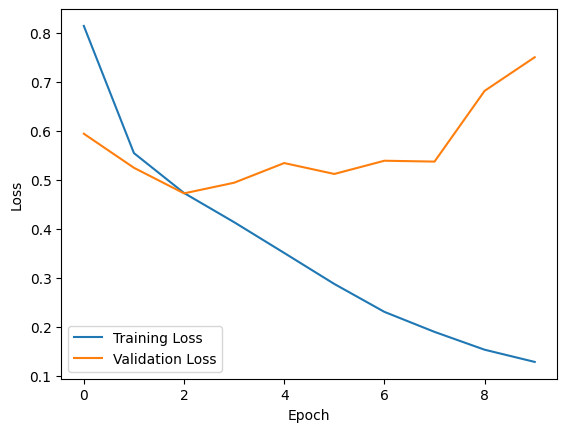

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

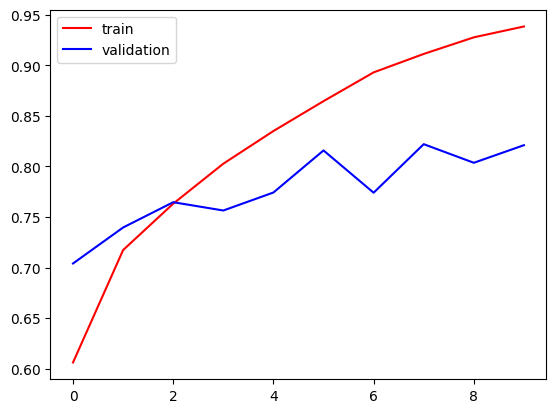

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

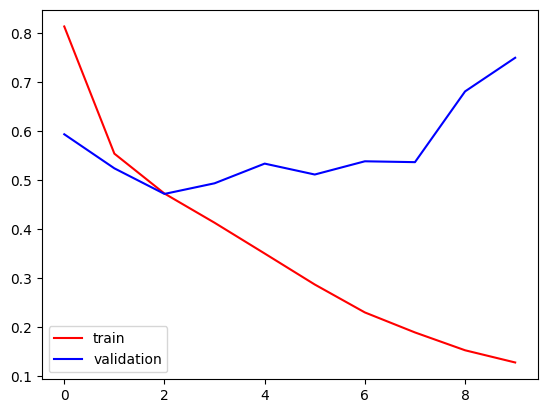

In [27]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [28]:
model.save('cats_and_dogs_classifier.h5')

In [ ]:
import cv2

In [ ]:
test_img = cv2.imread('/content/07CAT-STRIPES-mediumSquareAt3X-v2 (1).jpg')

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

In [ ]:
test_img = cv2.resize(test_img,(256,256))

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
import numpy as np
pred = model.predict(test_input)
print(pred)